# Dissolved Oxygen Sensor Analysis — Lake Taney Mooring

Analysis of the bottom dissolved oxygen record (miniDOT, 31.8 m) from the Lake Taney mooring, combined with the HOBO_T temperature chain and the Netatmo weather station. The notebook covers the DO timeseries, anoxia statistics, oxygen consumption rates, and the relationship between oxygen and meteorological forcing.

## 1. Setup and Data Import

Import of the required scientific libraries and loading of the Level-2 dissolved oxygen (DO) record from the miniDOT bottom sensor (31.8 m depth) on the Lake Taney mooring.

In [11]:
# Scientific stack: xarray for NetCDF/labelled arrays, pandas/numpy for
# tabular and numerical work, matplotlib for plotting,
# scipy.curve_fit for the exponential model fitting.
import xarray as xr
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
from scipy.optimize import curve_fit

In [12]:
# DATA IMPORT
df = xr.open_dataset('../data/Mooring/miniDOT/20260603/Level2/L2_mooring_minidot_583960.nc')
df

<xarray.Dataset> Size: 29MB
Dimensions:     (time: 521690)
Coordinates:
  * time        (time) datetime64[ns] 4MB 2025-06-06T06:57:00 ... 2026-06-03T...
    depth       float64 8B ...
    serial_id   <U6 24B ...
Data variables:
    Temp        (time) float64 4MB ...
    DO_mg       (time) float64 4MB ...
    sat         (time) float64 4MB ...
    DO_mg_qual  (time) int64 4MB ...
    sat_qual    (time) int64 4MB ...
    Temp_qual   (time) int64 4MB ...
Attributes: (12/15)
    xsc:          554076
    ysc:          132894
    deployment:   2025-06-06 09:30:00
    retrieval:    2026-06-03 12:00:00
    sensor:       minidot
    serial_id:    583960
    ...           ...
    source:       
    references:   Aquatic Science Master field camp
    history:      See history on Renku
    conventions:  CF 1.7
    comment:      Monitoring data in Lake Taney performed by Aquatic Science ...
    title:        Mooring Lake Taney

## 2. Dissolved Oxygen Timeseries

Overview of the full bottom DO record, with reference lines at the 4 mg/L regulatory threshold and the 2 mg/L hypoxia level.

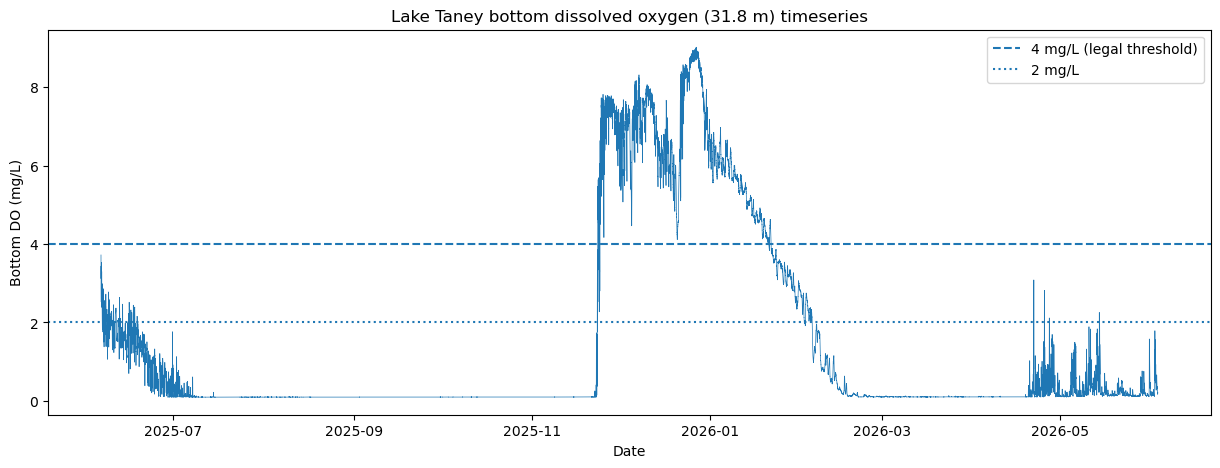

In [13]:
# Full-record plot of bottom dissolved oxygen through time
plt.figure(figsize=(15,5))

plt.plot(
    df["time"],
    df["DO_mg"],
    linewidth=0.5
)

# Reference lines: 4 mg/L legal threshold and 2 mg/L hypoxia level
plt.axhline(4, linestyle="--", label="4 mg/L (legal threshold)")
plt.axhline(2, linestyle=":", label="2 mg/L")

plt.ylabel("Bottom DO (mg/L)")
plt.xlabel("Date")
plt.title("Lake Taney bottom dissolved oxygen (31.8 m) timeseries")
plt.legend()


### Zoom on the spring mixing period

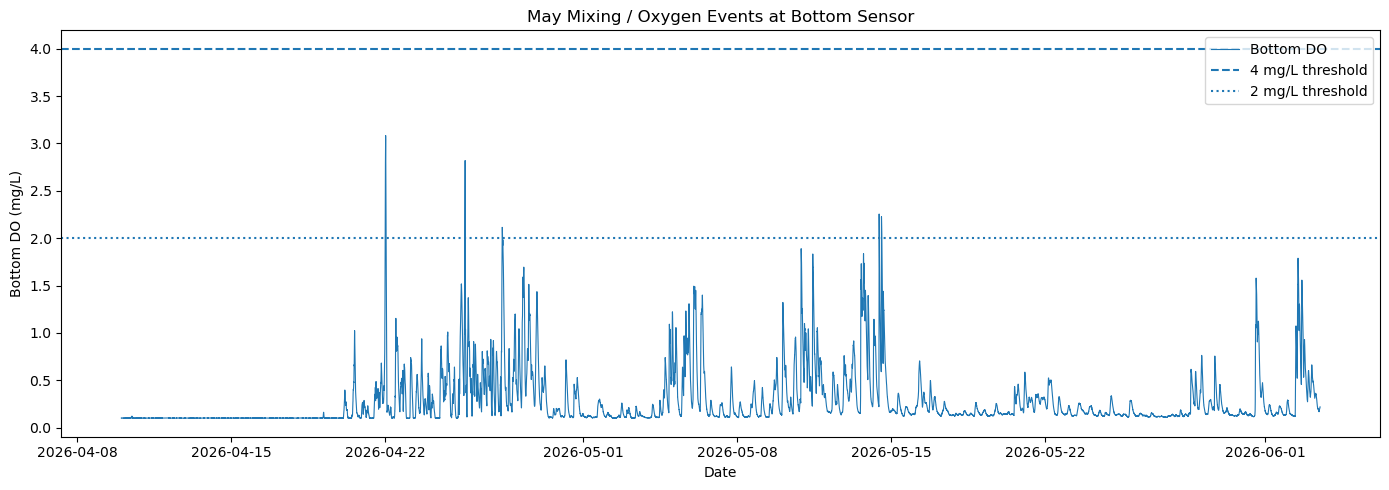

In [14]:
# ZOOM ON MAY MIXING PERIOD

# Restrict the dataset to the spring re-oxygenation window
may = df.sel(
    time=slice("2026-04-10", "2026-06-03")
)

plt.figure(figsize=(14, 5))

plt.plot(
    may["time"],
    may["DO_mg"],
    linewidth=0.8,
    label="Bottom DO"
)

plt.axhline(4, linestyle="--", label="4 mg/L threshold")
plt.axhline(2, linestyle=":", label="2 mg/L threshold")

plt.ylabel("Bottom DO (mg/L)")
plt.xlabel("Date")
plt.title("May Mixing / Oxygen Events at Bottom Sensor")
plt.legend()
plt.tight_layout()
plt.show()

### Dissolved oxygen vs bottom temperature

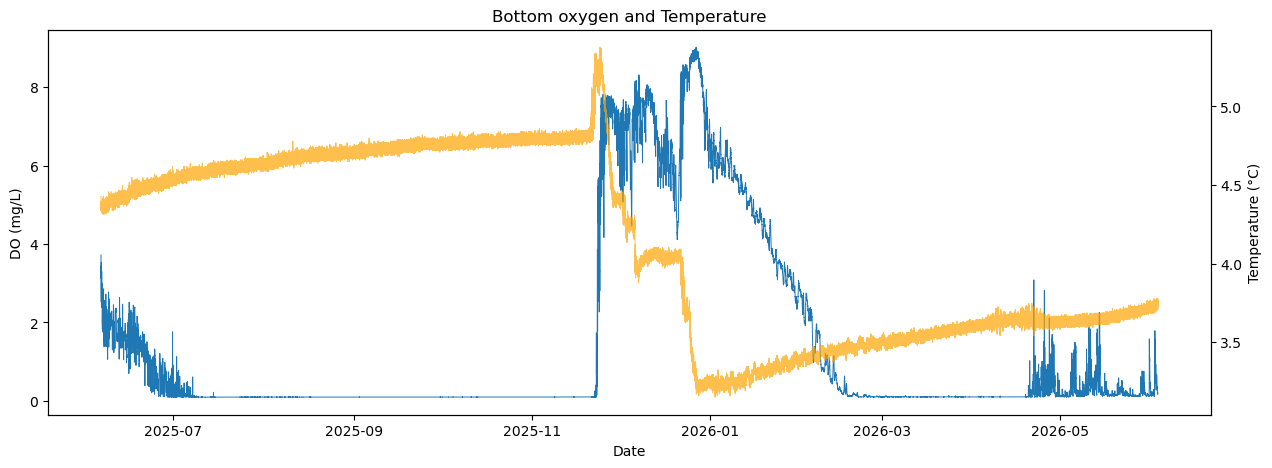

In [15]:
# DO and bottom temperature on twin y-axes to compare their dynamics
fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(
    df["time"],
    df["DO_mg"],
    linewidth=0.7,
    label="DO"
)

ax1.set_ylabel("DO (mg/L)")
ax1.set_xlabel("Date")

# Second y-axis sharing the same time axis, for temperature
ax2 = ax1.twinx()

ax2.plot(
    df["time"],
    df["Temp"],
    linewidth=0.7,
    alpha=0.7,
    color="orange",
    label="Temp"
)

ax2.set_ylabel("Temperature (°C)")

plt.title("Bottom oxygen and Temperature")

plt.show()

## 3. Anoxia: Seasonal and Monthly Statistics

Daily-averaged DO is classified relative to the 4 mg/L threshold to quantify how many days the bottom water spends above and below it, aggregated by season and by month.

In [16]:
# Resample and convert to pandas Series
daily_DO = df.DO_mg.resample(time='1D').mean().to_series()

# Create a function to assign seasons starting from winter (Dec-Feb)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Fall'

# Create a DataFrame for easier manipulation
df_do = pd.DataFrame({'DO': daily_DO})
df_do['season'] = df_do.index.month.map(get_season)
df_do['year'] = df_do.index.year

# Adjust year for winter months (Dec belongs to next year's winter)
df_do['year_adj'] = df_do['year'] + ((df_do['season'] == 'Winter') & (df_do.index.month == 12)).astype(int)

# Create season-year label
df_do['season_year'] = df_do['season'] + '_' + df_do['year_adj'].astype(str)

# Count days above and below 4 mg/L per season
# For each season, count the days spent above vs below the 4 mg/L threshold
dd_per_season_abv4 = (df_do['DO'] > 4).groupby(df_do['season_year']).sum()
dd_per_season_blw4 = (df_do['DO'] < 4).groupby(df_do['season_year']).sum()

# Calculate total days and percentages per season
total_days_per_season = dd_per_season_abv4 + dd_per_season_blw4
pct_abv4 = (dd_per_season_abv4 / total_days_per_season * 100).round(1)
pct_blw4 = (dd_per_season_blw4 / total_days_per_season * 100).round(1)

# Monthly statistics
# Same above/below-threshold counting, but aggregated by calendar month
df_do['year_month'] = df_do.index.to_period('M')
dd_per_month_abv4 = (df_do['DO'] > 4).groupby(df_do['year_month']).sum()
dd_per_month_blw4 = (df_do['DO'] < 4).groupby(df_do['year_month']).sum()
total_days_per_month = dd_per_month_abv4 + dd_per_month_blw4
pct_month_abv4 = (dd_per_month_abv4 / total_days_per_month * 100).round(1)
pct_month_blw4 = (dd_per_month_blw4 / total_days_per_month * 100).round(1)

print('=== SEASONAL STATISTICS ===')
print('\nNumber of days above 4 mg/L per season:')
print(dd_per_season_abv4)
print('\nNumber of days below 4 mg/L (anoxic) per season:')
print(dd_per_season_blw4)
print('\nTotal days per season:')
print(total_days_per_season)
print('\nPercentage of days above 4 mg/L per season (%):')
print(pct_abv4)
print('\nPercentage of days below 4 mg/L (anoxic) per season (%):')
print(pct_blw4)

print('\n=== MONTHLY STATISTICS ===')
print('\nNumber of days above 4 mg/L per month:')
print(dd_per_month_abv4)
print('\nNumber of days below 4 mg/L (anoxic) per month:')
print(dd_per_month_blw4)
print('\nPercentage of days above 4 mg/L per month (%):')
print(pct_month_abv4)
print('\nPercentage of days below 4 mg/L (anoxic) per month (%):')
print(pct_month_blw4)

print('\nDaily min:', daily_DO.min())
print('Daily max:', daily_DO.max())

# Rename Winter_2026 to Winter_2025 as requested
if 'Winter_2026' in dd_per_season_abv4.index:
    dd_per_season_abv4 = dd_per_season_abv4.rename({'Winter_2026': 'Winter_2025'})
    dd_per_season_blw4 = dd_per_season_blw4.rename({'Winter_2026': 'Winter_2025'})
    pct_abv4 = pct_abv4.rename({'Winter_2026': 'Winter_2025'})
    pct_blw4 = pct_blw4.rename({'Winter_2026': 'Winter_2025'})

# Reorder seasonal data chronologically from Summer 2025 to Summer 2026
# Force chronological season order for plotting
season_order = ['Summer_2025', 'Fall_2025', 'Winter_2025', 'Spring_2026', 'Summer_2026']
dd_per_season_abv4_sorted = dd_per_season_abv4.reindex([s for s in season_order if s in dd_per_season_abv4.index])
dd_per_season_blw4_sorted = dd_per_season_blw4.reindex([s for s in season_order if s in dd_per_season_blw4.index])
pct_abv4_sorted = pct_abv4.reindex([s for s in season_order if s in pct_abv4.index])
pct_blw4_sorted = pct_blw4.reindex([s for s in season_order if s in pct_blw4.index])


=== SEASONAL STATISTICS ===

Number of days above 4 mg/L per season:
season_year
Fall_2025       7
Spring_2026     0
Summer_2025     0
Summer_2026     0
Winter_2026    52
Name: DO, dtype: int64

Number of days below 4 mg/L (anoxic) per season:
season_year
Fall_2025      84
Spring_2026    92
Summer_2025    87
Summer_2026     3
Winter_2026    38
Name: DO, dtype: int64

Total days per season:
season_year
Fall_2025      91
Spring_2026    92
Summer_2025    87
Summer_2026     3
Winter_2026    90
Name: DO, dtype: int64

Percentage of days above 4 mg/L per season (%):
season_year
Fall_2025       7.7
Spring_2026     0.0
Summer_2025     0.0
Summer_2026     0.0
Winter_2026    57.8
Name: DO, dtype: float64

Percentage of days below 4 mg/L (anoxic) per season (%):
season_year
Fall_2025       92.3
Spring_2026    100.0
Summer_2025    100.0
Summer_2026    100.0
Winter_2026     42.2
Name: DO, dtype: float64

=== MONTHLY STATISTICS ===

Number of days above 4 mg/L per month:
year_month
2025-06     0
202

### Visual summary: daily timeseries, seasonal and monthly counts

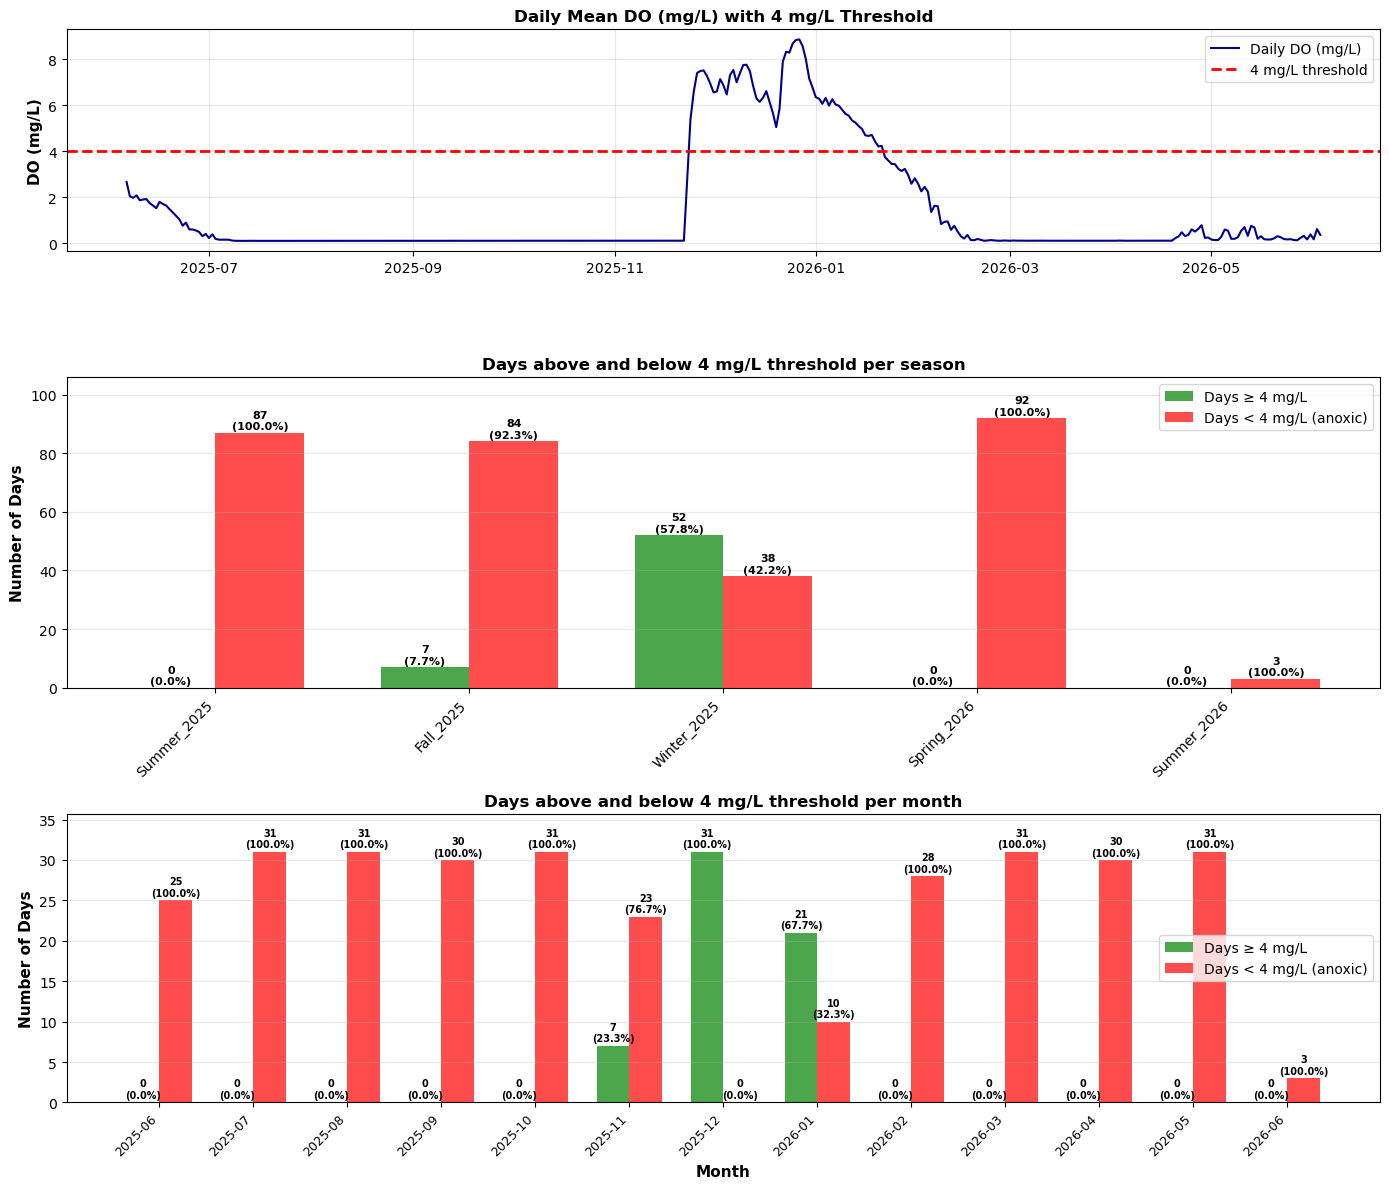

In [17]:
# Create a comprehensive 3-panel figure with timeseries, seasonal, and monthly analysis
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1.4, 1.3]})

# Panel 1: Daily DO timeseries with thresholds
ax1.plot(daily_DO.index, daily_DO.values, color='darkblue', linewidth=1.5, label='Daily DO (mg/L)')
ax1.axhline(4, color='red', linestyle='--', linewidth=2, label='4 mg/L threshold')
ax1.grid(True, alpha=0.3)
ax1.set_title('Daily Mean DO (mg/L) with 4 mg/L Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('DO (mg/L)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10, loc='best')

# Panel 2: Seasonal histogram (ordered chronologically)
# Grouped bar chart: green = oxygenated days, red = anoxic days, per season
x_pos_season = np.arange(len(dd_per_season_abv4_sorted))
width = 0.35
ax2.bar(x_pos_season - width/2, dd_per_season_abv4_sorted.values, width, label='Days ≥ 4 mg/L', color='green', alpha=0.7)
ax2.bar(x_pos_season + width/2, dd_per_season_blw4_sorted.values, width, label='Days < 4 mg/L (anoxic)', color='red', alpha=0.7)

# Add labels on seasonal bars
for i, (abv, blw, pct_a, pct_b) in enumerate(zip(dd_per_season_abv4_sorted.values, dd_per_season_blw4_sorted.values, pct_abv4_sorted.values, pct_blw4_sorted.values)):
    ax2.text(i - width/2, abv + 0.5, f'{int(abv)}\n({pct_a}%)', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax2.text(i + width/2, blw + 0.5, f'{int(blw)}\n({pct_b}%)', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_ylabel('Number of Days', fontsize=11, fontweight='bold')
ax2.set_title('Days above and below 4 mg/L threshold per season', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos_season)
ax2.set_xticklabels(dd_per_season_abv4_sorted.index, rotation=45, ha='right')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.margins(y=0.15)

# Panel 3: Monthly histogram
# Same grouped bars but resolved month by month
x_pos_month = np.arange(len(dd_per_month_abv4))
width = 0.35
ax3.bar(x_pos_month - width/2, dd_per_month_abv4.values, width, label='Days ≥ 4 mg/L', color='green', alpha=0.7)
ax3.bar(x_pos_month + width/2, dd_per_month_blw4.values, width, label='Days < 4 mg/L (anoxic)', color='red', alpha=0.7)

# Add labels on monthly bars
for i, (abv, blw, pct_a, pct_b) in enumerate(zip(dd_per_month_abv4.values, dd_per_month_blw4.values, pct_month_abv4.values, pct_month_blw4.values)):
    ax3.text(i - width/2, abv + 0.3, f'{int(abv)}\n({pct_a}%)', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax3.text(i + width/2, blw + 0.3, f'{int(blw)}\n({pct_b}%)', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax3.set_xlabel('Month', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of Days', fontsize=11, fontweight='bold')
ax3.set_title('Days above and below 4 mg/L threshold per month', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos_month)
ax3.set_xticklabels([str(m) for m in dd_per_month_abv4.index], rotation=45, ha='right', fontsize=9)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.margins(y=0.15)

plt.tight_layout()
plt.show()

## 4. Dissolved Oxygen and Temperature (miniDOT & HOBO_T)

The bottom DO signal is compared with the mooring temperature and with the HOBO_T thermistor chain (sensors 2, 5 and 9) to relate oxygen dynamics to thermal stratification.

In [18]:
# HOBO_T DATA IMPORT

# Load the three HOBO_T thermistors: 2 (bottom), 5 (middle), 9 (surface)
dfTS2 = xr.open_dataset('../data/Mooring/HOBO_T/20260603/Level2/L2_mooring_csv_T_Sensor_Number_2_20250606_091613.nc')
dfTS2 # DATA SENSOR 2
dfTS5 = xr.open_dataset('../data/Mooring/HOBO_T/20260603/Level2/L2_mooring_csv_T_Sensor_Number_5_20250606_090804.nc')
dfTS5 # DATA SENSOR 5
dfTS9 = xr.open_dataset('../data/Mooring/HOBO_T/20260603/Level2/L2_mooring_csv_T_Sensor_Number_9_20250606_090418.nc')
dfTS9 # DATA SENSOR 9

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 52176)
Coordinates:
  * time       (time) datetime64[ns] 417kB 2025-06-06T09:04:18 ... 2026-06-03...
Data variables:
    Temp       (time) float64 417kB ...
    Temp_qual  (time) float64 417kB ...
Attributes: (12/18)
    institution:            Unil
    source:                 
    references:             Aquatic Science Master field camp
    history:                See history on Renku
    conventions:            CF 1.7
    comment:                Monitoring data in Lake Taney performed by Aquati...
    ...                     ...
    Altitude (m):           1405
    timezone_note:          Thermistor timestamps are local civil time WITH d...
    failed_sensors:         {"sensor_number": 1, "reference": "21724000", "ch...
    Depth (m):              1.62
    latitude:               46.345849411373834
    longitude:              6.841894205156098

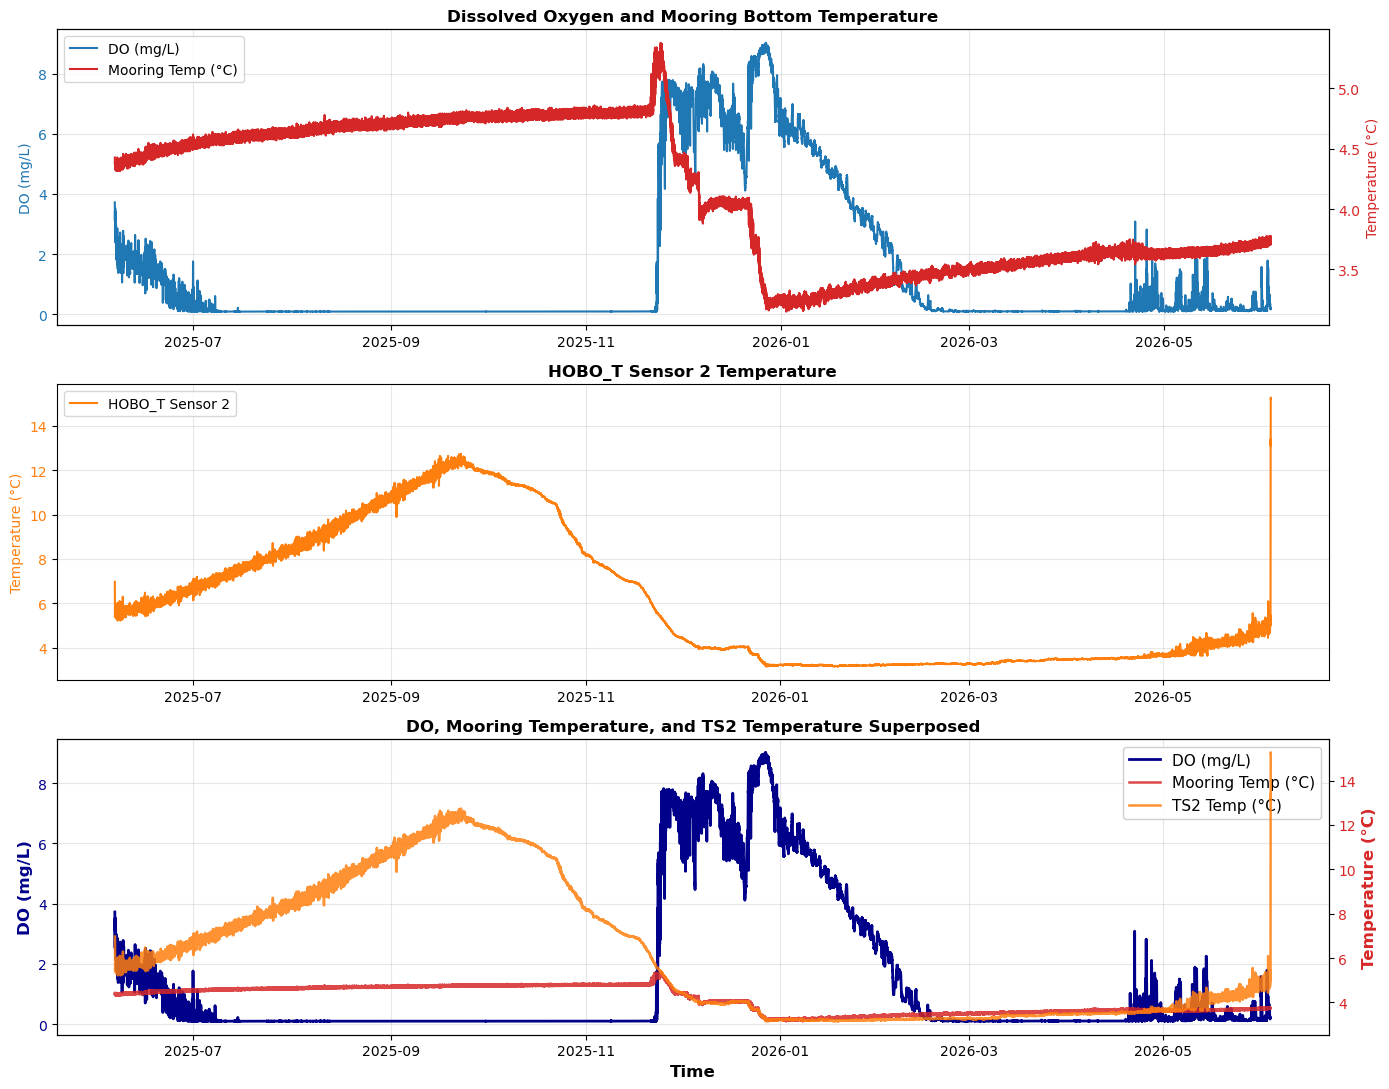

In [19]:
# Create an additional plot with all temperature sensors superposed
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Plot 1: DO and Mooring Temperature
ax1 = axes[0]
ax1_twin = ax1.twinx()
color1 = 'tab:blue'
ax1.set_ylabel('DO (mg/L)', color=color1)
line1 = ax1.plot(df.time, df.DO_mg, color=color1, linewidth=1.5, label='DO (mg/L)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

color2 = 'tab:red'
ax1_twin.set_ylabel('Temperature (°C)', color=color2)
line2 = ax1_twin.plot(df.time, df.Temp, color=color2, linewidth=1.5, label='Mooring Temp (°C)')
ax1_twin.tick_params(axis='y', labelcolor=color2)
ax1.set_title('Dissolved Oxygen and Mooring Bottom Temperature', fontsize=12, fontweight='bold')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Plot 2: HOBO_T Sensor 2
ax2 = axes[1]
ax2.plot(dfTS2.time, dfTS2.Temp, color='tab:orange', linewidth=1.5, label='HOBO_T Sensor 2')
ax2.set_ylabel('Temperature (°C)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.grid(True, alpha=0.3)
ax2.set_title('HOBO_T Sensor 2 Temperature', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left')

# Plot 3: DO, Mooring Temperature, and HOBO_T Sensor 2 superposed
ax3 = axes[2]
ax3_twin = ax3.twinx()
color_do = 'darkblue'
color_temp = 'tab:red'
color_ts2 = 'tab:orange'

# Bottom panel overlays DO with both mooring and TS2 temperature
line3_do = ax3.plot(df.time, df.DO_mg, color=color_do, linewidth=2, label='DO (mg/L)', zorder=3)
ax3.set_ylabel('DO (mg/L)', fontsize=12, fontweight='bold', color=color_do)
ax3.tick_params(axis='y', labelcolor=color_do)
ax3.grid(True, alpha=0.3)

line3_temp = ax3_twin.plot(df.time, df.Temp, color=color_temp, linewidth=1.8, label='Mooring Temp (°C)', alpha=0.85, zorder=2)
line3_ts2 = ax3_twin.plot(dfTS2.time, dfTS2.Temp, color=color_ts2, linewidth=1.8, label='TS2 Temp (°C)', alpha=0.85, zorder=2)
ax3_twin.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold', color=color_temp)
ax3_twin.tick_params(axis='y', labelcolor=color_temp)

ax3.set_xlabel('Time', fontsize=12, fontweight='bold')
ax3.set_title('DO, Mooring Temperature, and TS2 Temperature Superposed', fontsize=12, fontweight='bold')
lines3 = line3_do + line3_temp + line3_ts2
labels3 = [l.get_label() for l in lines3]
ax3.legend(lines3, labels3, loc='best', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.show()

### Temperature across the water column

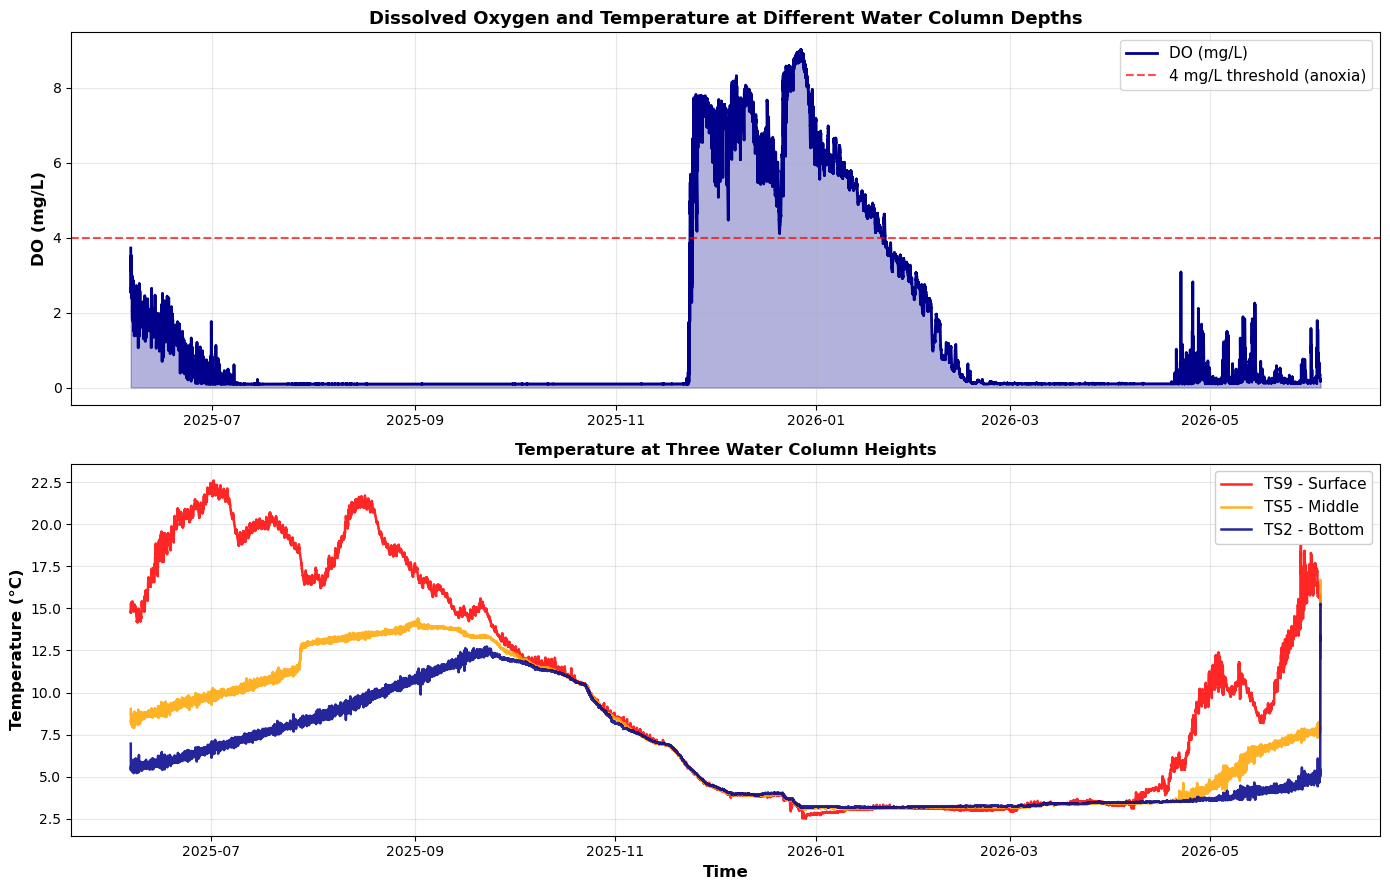

In [20]:
# Create a comprehensive plot of DO and temperature at three depths
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Plot 1: Dissolved Oxygen
ax1 = axes[0]
ax1.plot(df.time, df.DO_mg, color='darkblue', linewidth=2, label='DO (mg/L)')
ax1.fill_between(df.time, df.DO_mg, alpha=0.3, color='darkblue')
ax1.axhline(4, color='red', linestyle='--', linewidth=1.5, label='4 mg/L threshold (anoxia)', alpha=0.7)
ax1.set_ylabel('DO (mg/L)', fontsize=12, fontweight='bold')
ax1.set_title('Dissolved Oxygen and Temperature at Different Water Column Depths', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=11)

# Plot 2: Temperature at three depths
ax2 = axes[1]
# Surface-to-bottom temperature, to visualise thermal stratification
ax2.plot(dfTS9.time, dfTS9.Temp, color='red', linewidth=1.8, label='TS9 - Surface', alpha=0.85)
ax2.plot(dfTS5.time, dfTS5.Temp, color='orange', linewidth=1.8, label='TS5 - Middle', alpha=0.85)
ax2.plot(dfTS2.time, dfTS2.Temp, color='darkblue', linewidth=1.8, label='TS2 - Bottom', alpha=0.85)
ax2.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time', fontsize=12, fontweight='bold')
ax2.set_title('Temperature at Three Water Column Heights', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.show()

## 5. Oxygen Consumption Rate Analysis

Estimation of how fast bottom oxygen is depleted or replenished, first with linear regression over selected periods and then with an exponential decay/recovery model.

### 5.1 Linear consumption rates per period

In [21]:
# Daily means of DO and temperature, used as the basis for rate fits
daily = (
    df[['DO_mg', 'Temp']]
    .resample(time='1D')
    .mean()
    .to_dataframe()
    .reset_index()
    .set_index('time')
    .dropna()
)

daily.head()

# Fit a straight line (slope = mg/L per day) over a chosen date range
def rate_for_period(daily, start, end, ycol="DO_mg"):
    """
    Calculate the linear regression slope for a given period
    """
    try:
        sub = daily.loc[start:end].copy()
        if sub.empty:
            print(f"Warning: No data found for period {start} to {end}")
            return sub, np.nan, np.nan
        
        sub = sub.dropna(subset=[ycol])
        if len(sub) < 2:
            print(f"Warning: Not enough data points for period {start} to {end}")
            return sub, np.nan, np.nan
        
        x = np.arange(len(sub))
        y = sub[ycol].values
        
        slope, intercept = np.polyfit(x, y, 1)
        return sub, slope, intercept
    except Exception as e:
        print(f"Error calculating rate for {start} to {end}: {e}")
        return None, np.nan, np.nan

# Calculate rates for different periods
print("=== OXYGEN RATE ANALYSIS ===\n")

# Apply the linear fit to summer, winter, autumn mixing and May periods
summer, summer_slope, summer_intercept = rate_for_period(
    daily,
    "2025-06-06",
    "2025-07-15"
)
if not np.isnan(summer_slope):
    print(f"Summer (Jun 6 - Jul 15, 2025):")
    print(f"  Oxygen change rate: {summer_slope:.3f} mg/L/day")
    print(f"  Oxygen consumption rate: {-summer_slope:.3f} mg/L/day\n")

winter, winter_slope, winter_intercept = rate_for_period(
    daily,
    "2026-01-01",
    "2026-03-01"
)
if not np.isnan(winter_slope):
    print(f"Winter (Jan 1 - Mar 1, 2026):")
    print(f"  Oxygen change rate: {winter_slope:.3f} mg/L/day")
    print(f"  Oxygen consumption rate: {-winter_slope:.3f} mg/L/day\n")

mixing, mixing_slope, mixing_intercept = rate_for_period(
    daily,
    "2025-11-20",
    "2025-12-05"
)
if not np.isnan(mixing_slope):
    print(f"Mixing Period (Nov 20 - Dec 5, 2025):")
    print(f"  Oxygen increase rate: {mixing_slope:.3f} mg/L/day\n")

may, may_slope, may_intercept = rate_for_period(
    daily,
    "2026-05-01",
    "2026-06-03"
)
if not np.isnan(may_slope):
    print(f"May-June (May 1 - Jun 3, 2026):")
    print(f"  Oxygen change rate: {may_slope:.3f} mg/L/day")

=== OXYGEN RATE ANALYSIS ===

Summer (Jun 6 - Jul 15, 2025):
  Oxygen change rate: -0.064 mg/L/day
  Oxygen consumption rate: 0.064 mg/L/day

Winter (Jan 1 - Mar 1, 2026):
  Oxygen change rate: -0.127 mg/L/day
  Oxygen consumption rate: 0.127 mg/L/day

Mixing Period (Nov 20 - Dec 5, 2025):
  Oxygen increase rate: 0.448 mg/L/day

May-June (May 1 - Jun 3, 2026):
  Oxygen change rate: -0.002 mg/L/day


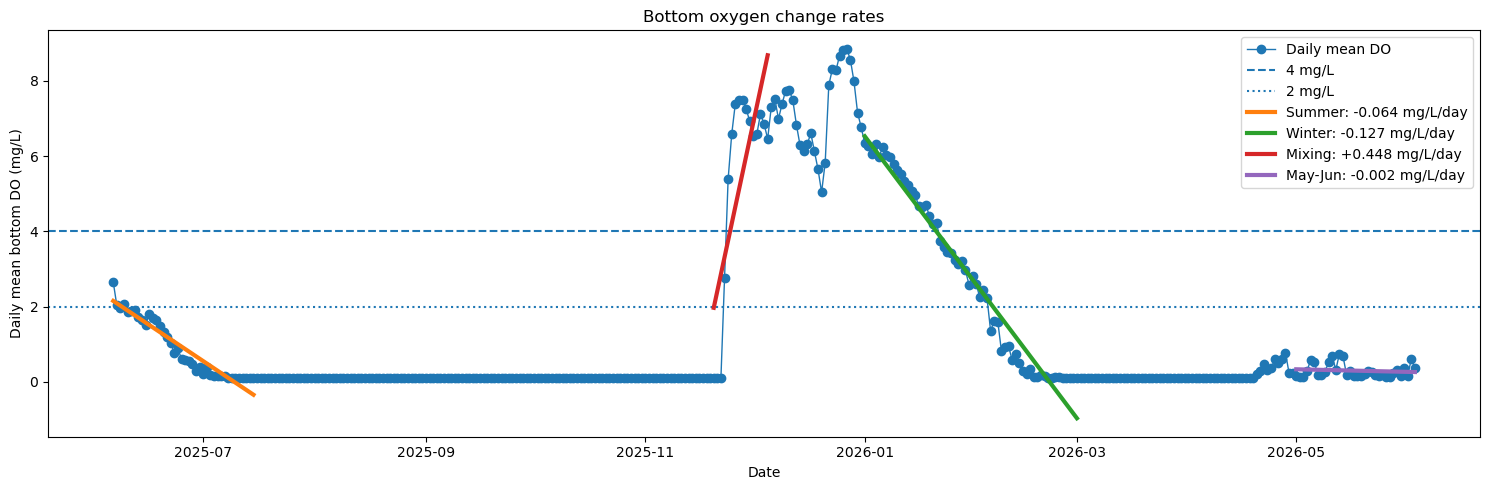

In [22]:
plt.figure(figsize=(15,5))

plt.plot(
    daily.index,
    daily["DO_mg"],
    marker="o",
    linewidth=1,
    label="Daily mean DO"
)

plt.axhline(4, linestyle="--", label="4 mg/L")
plt.axhline(2, linestyle=":", label="2 mg/L")

# Summer
# Overlay each fitted linear trend on the daily DO series
x_summer = np.arange(len(summer))
plt.plot(
    summer.index,
    summer_slope * x_summer + summer_intercept,
    linewidth=3,
    label=f"Summer: {summer_slope:.3f} mg/L/day"
)

# Winter
x_winter = np.arange(len(winter))
plt.plot(
    winter.index,
    winter_slope * x_winter + winter_intercept,
    linewidth=3,
    label=f"Winter: {winter_slope:.3f} mg/L/day"
)

# Mixing
x_mixing = np.arange(len(mixing))
plt.plot(
    mixing.index,
    mixing_slope * x_mixing + mixing_intercept,
    linewidth=3,
    label=f"Mixing: +{mixing_slope:.3f} mg/L/day"
)

# May–June
x_may = np.arange(len(may))
plt.plot(
    may.index,
    may_slope * x_may + may_intercept,
    linewidth=3,
    label=f"May-Jun: {may_slope:.3f} mg/L/day"
)

plt.ylabel("Daily mean bottom DO (mg/L)")
plt.xlabel("Date")
plt.title("Bottom oxygen change rates")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Richer daily table: mean/min/max of DO and temperature per day
daily = (
    df
    .to_dataframe()
    .reset_index()
    .set_index("time")
    .resample("D")
    .agg(
        DO_mean=("DO_mg", "mean"),
        DO_min=("DO_mg", "min"),
        DO_max=("DO_mg", "max"),
        Temp_mean=("Temp", "mean"),
        Temp_min=("Temp", "min"),
        Temp_max=("Temp", "max"),
    )
    .dropna()
)

In [24]:
# Linear-slope helper, here using actual day offsets as the x-axis
def rate_for_period(daily, start, end, ycol="DO_mean"):
    sub = daily.loc[start:end].copy()
    sub = sub.dropna(subset=[ycol])

    x = (sub.index - sub.index[0]).days.values
    y = sub[ycol].values

    slope, intercept = np.polyfit(x, y, 1)

    return sub, slope, intercept

### 5.2 Exponential decay and recovery model

In [25]:
# Exponential depletion model: DO decays toward 0 at rate k
def exp_decay(t, DO0, k):
    return DO0 * np.exp(-k * t)

# Exponential recovery model: DO rises toward DOmax at rate k
def exp_increase(t, DO0, DOmax, k):
    return DOmax - (DOmax - DO0) * np.exp(-k * t)

# Fit the decay model to a period via non-linear least squares
def fit_exp_decay(daily, start, end):
    sub = daily.loc[start:end].copy()
    sub = sub[sub["DO_mean"] > 0.05].copy()

    t = (sub.index - sub.index[0]).days.values
    y = sub["DO_mean"].values

    popt, pcov = curve_fit(
        exp_decay,
        t,
        y,
        p0=[y[0], 0.05],
        maxfev=10000
    )

    DO0, k = popt
    yfit = exp_decay(t, DO0, k)

    return sub, t, yfit, DO0, k

# Fit the recovery model (bounded parameters) to a period
def fit_exp_increase(daily, start, end):
    sub = daily.loc[start:end].copy()
    sub = sub[sub["DO_mean"] > 0.05].copy()

    t = (sub.index - sub.index[0]).days.values
    y = sub["DO_mean"].values

    popt, pcov = curve_fit(
        exp_increase,
        t,
        y,
        p0=[y[0], y.max(), 0.2],
        bounds=([0, 0, 0], [20, 20, 5]),
        maxfev=10000
    )

    DO0, DOmax, k = popt
    yfit = exp_increase(t, DO0, DOmax, k)

    return sub, t, yfit, DO0, DOmax, k

In [26]:
# Fit decay in summer and winter, and recovery during autumn mixing
summer, t_summer, summer_fit, summer_DO0, summer_k = fit_exp_decay(
    daily,
    "2025-06-06",
    "2025-07-25"
)

winter, t_winter, winter_fit, winter_DO0, winter_k = fit_exp_decay(
    daily,
    "2025-12-27",
    "2026-03-01"
)

mixing, t_mixing, mixing_fit, mixing_DO0, mixing_DOmax, mixing_k = fit_exp_increase(
    daily,
    "2025-11-20",
    "2025-12-15"
)

print("Summer decay")
print(f"DO0 = {summer_DO0:.2f} mg/L")
print(f"k = {summer_k:.4f} day^-1")

print("\nWinter decay")
print(f"DO0 = {winter_DO0:.2f} mg/L")
print(f"k = {winter_k:.4f} day^-1")

print("\nMixing increase")
print(f"DO0 = {mixing_DO0:.2f} mg/L")
print(f"DOmax = {mixing_DOmax:.2f} mg/L")
print(f"k = {mixing_k:.4f} day^-1")

Summer decay
DO0 = 2.64 mg/L
k = 0.0686 day^-1

Winter decay
DO0 = 8.93 mg/L
k = 0.0394 day^-1

Mixing increase
DO0 = 0.00 mg/L
DOmax = 7.30 mg/L
k = 0.2702 day^-1


In [27]:
# Invert the decay model to estimate days needed to reach a DO threshold
def time_to_threshold_decay(DO0, k, threshold):
    return np.log(DO0 / threshold) / k

for name, DO0, k in [
    ("Summer", summer_DO0, summer_k),
    ("Winter", winter_DO0, winter_k),
]:
    if DO0 > 4:
        days_to_4 = time_to_threshold_decay(DO0, k, 4)
        print(f"{name}: estimated time to 4 mg/L = {days_to_4:.1f} days")
    else:
        print(f"{name}: DO0 is already below 4 mg/L")

Summer: DO0 is already below 4 mg/L
Winter: estimated time to 4 mg/L = 20.4 days


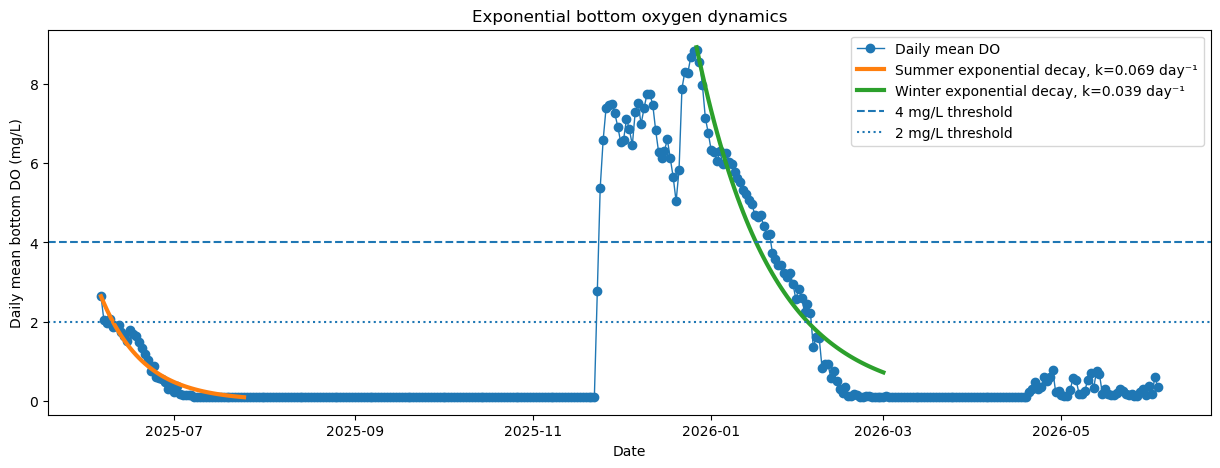

In [28]:
plt.figure(figsize=(15,5))

plt.plot(
    daily.index,
    daily["DO_mean"],
    marker="o",
    linewidth=1,
    label="Daily mean DO"
)

plt.plot(
    # Overlay the fitted exponential curves on the observations
    summer.index,
    summer_fit,
    linewidth=3,
    label=f"Summer exponential decay, k={summer_k:.3f} day⁻¹"
)

plt.plot(
    winter.index,
    winter_fit,
    linewidth=3,
    label=f"Winter exponential decay, k={winter_k:.3f} day⁻¹"
)


plt.axhline(4, linestyle="--", label="4 mg/L threshold")
plt.axhline(2, linestyle=":", label="2 mg/L threshold")

plt.ylabel("Daily mean bottom DO (mg/L)")
plt.xlabel("Date")
plt.title("Exponential bottom oxygen dynamics")
plt.legend()
plt.show()

### 5.3 Near-anoxic episodes

In [29]:
# Flag near-anoxic samples (<= 0.4 mg/L) and count their share
anoxia = df["DO_mg"] <= 0.4

n_anoxic_records = anoxia.sum().item()
pct_anoxic_records = 100 * anoxia.mean().item()

# Count days whose daily mean is near-anoxic
daily_mean = df["DO_mg"].resample(time="1D").mean()

n_anoxic_days = (daily_mean <= 0.4).sum().item()

print(f"Anoxic records: {n_anoxic_records}")
print(f"Percent of records anoxic: {pct_anoxic_records:.1f}%")
print(f"Anoxic days: {n_anoxic_days}")

Anoxic records: 354669
Percent of records anoxic: 68.0%
Anoxic days: 245


In [30]:
threshold = 0.4

anoxia = df["DO_mg"] <= threshold

n_anoxic_records = anoxia.sum().item()
pct_anoxic_records = 100 * anoxia.mean().item()

daily = (
    df["DO_mg"]
    .resample(time="1D")
    .mean()
    .to_dataframe(name="DO_mean")
    .dropna()
)

n_anoxic_days = (daily["DO_mean"] <= threshold).sum()

# Mark near-anoxic days...
daily["low_O2"] = daily["DO_mean"] <= threshold

# ...then group consecutive near-anoxic days into distinct episodes
daily["group"] = (
    daily["low_O2"] != daily["low_O2"].shift()
).cumsum()

periods = (
    daily[daily["low_O2"]]
    .groupby("group")
    .agg(
        start=("low_O2", lambda x: x.index.min()),
        end=("low_O2", lambda x: x.index.max())
    )
)

if len(periods) > 0:
    # Episode length in days; the longest one is reported below
    periods["duration_days"] = (
        periods["end"] - periods["start"]
    ).dt.days + 1

    periods = periods.sort_values(
        "duration_days",
        ascending=False
    )

    longest = periods.iloc[0]

    print(f"Anoxic records: {n_anoxic_records}")
    print(f"Percent of records anoxic: {pct_anoxic_records:.1f}%")
    print(f"Anoxic days: {n_anoxic_days}")
    print(f"Number of anoxic episodes: {len(periods)}")
    print(f"Longest episode: {longest['duration_days']} days")
    print(f"Start: {longest['start']}")
    print(f"End: {longest['end']}")

    display(periods)

else:
    print(f"Anoxic records: {n_anoxic_records}")
    print(f"Percent of records anoxic: {pct_anoxic_records:.1f}%")
    print(f"Anoxic days: {n_anoxic_days}")
    print("No anoxic episodes found.")

Anoxic records: 354669
Percent of records anoxic: 68.0%
Anoxic days: 245
Number of anoxic episodes: 8
Longest episode: 147 days
Start: 2025-06-29 00:00:00
End: 2025-11-22 00:00:00


,start,end,duration_days
group,,,
2,2025-06-29,2025-11-22,147
4,2026-02-14,2026-04-21,67
14,2026-05-15,2026-06-01,18
8,2026-04-29,2026-05-04,6
10,2026-05-07,2026-05-09,3
6,2026-04-23,2026-04-24,2
12,2026-05-12,2026-05-12,1
16,2026-06-03,2026-06-03,1


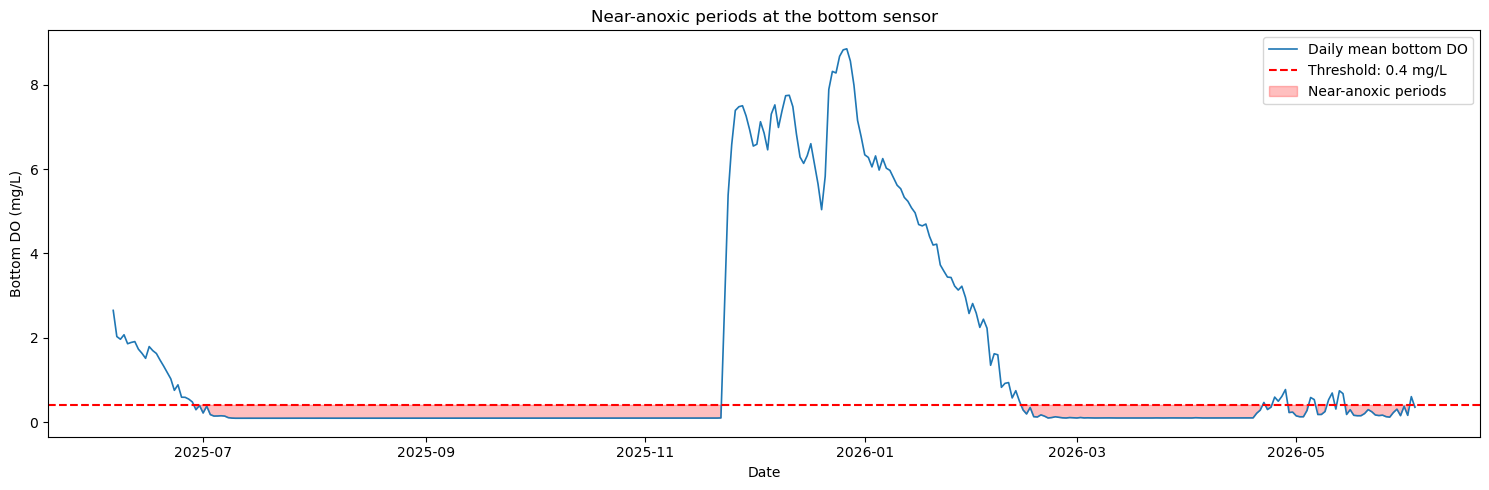

In [31]:
threshold = 0.4

daily = (
    df["DO_mg"]
    .resample(time="1D")
    .mean()
    .to_dataframe(name="DO_mean")
    .dropna()
)

daily["anoxic"] = daily["DO_mean"] <= threshold

plt.figure(figsize=(15,5))

plt.plot(
    daily.index,
    daily["DO_mean"],
    linewidth=1.2,
    label="Daily mean bottom DO"
)

plt.axhline(
    threshold,
    linestyle="--",
    color="red",
    label=f"Threshold: {threshold} mg/L"
)

# Shade the stretches where daily DO drops to the near-anoxic threshold
plt.fill_between(
    daily.index,
    daily["DO_mean"],
    threshold,
    where=daily["anoxic"],
    color="red",
    alpha=0.25,
    label="Near-anoxic periods"
)

plt.ylabel("Bottom DO (mg/L)")
plt.xlabel("Date")
plt.title("Near-anoxic periods at the bottom sensor")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Meteorological Forcing and Oxygen

The DO record is compared with air temperature and wind speed from the Netatmo weather station to investigate the atmospheric drivers of bottom oxygenation, focusing on the autumn mixing event.

In [33]:
# Load the Netatmo weather station and extract air temperature and wind
dfMETEO = xr.open_dataset('../data/Meteo/Station/20260521/Level2/L2_meteo_netatmo_netatmo_taney.nc')
dfMETEO

AirT = dfMETEO.Temp
WindS = dfMETEO.wind_speed

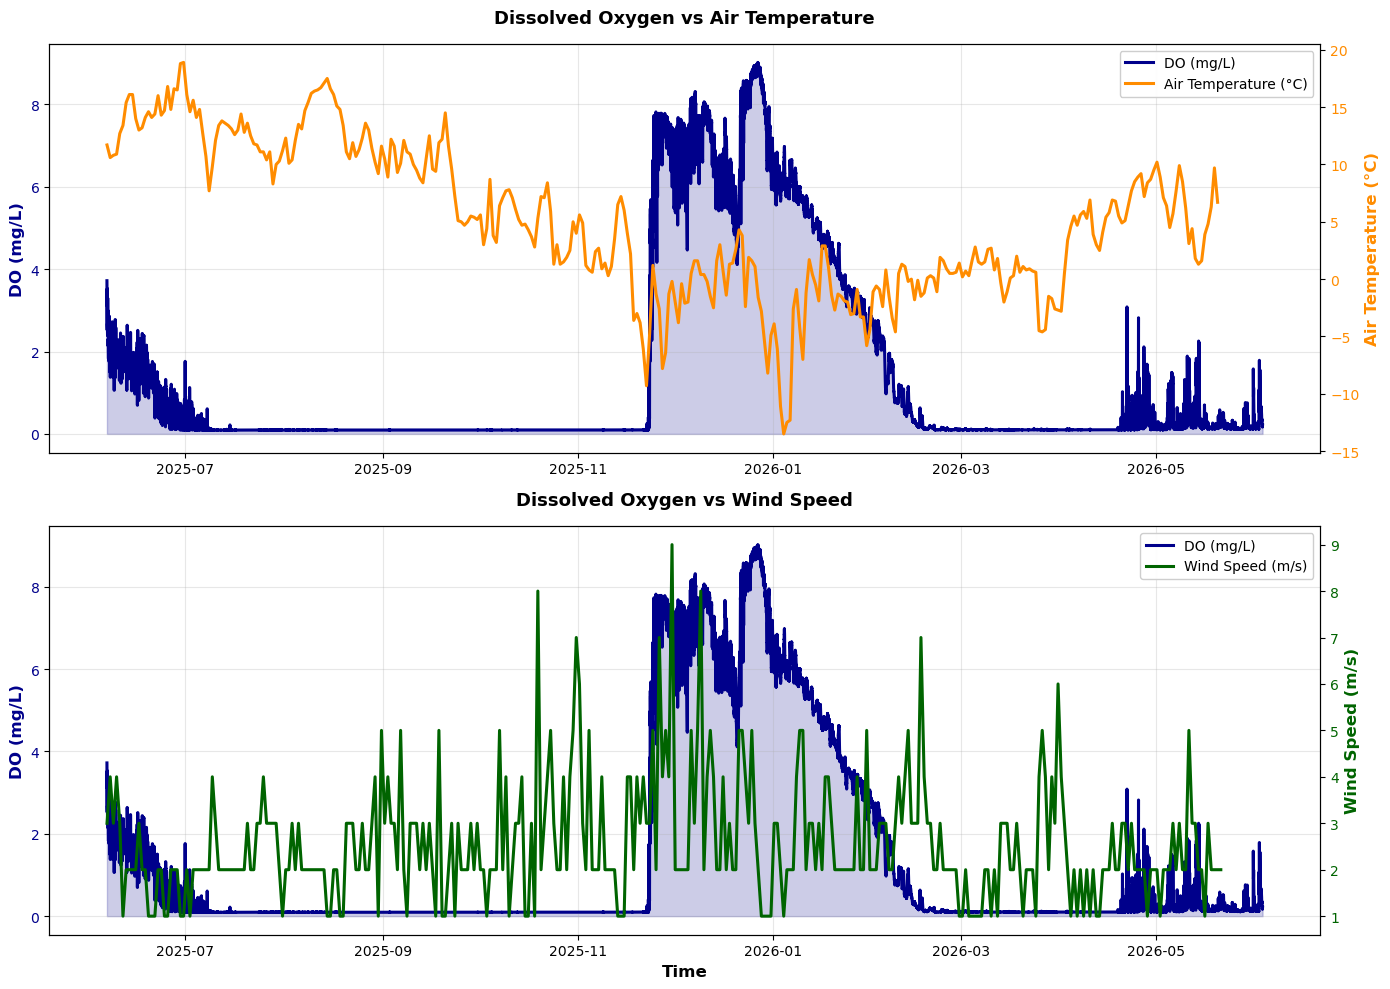

In [34]:
# Create two stacked plots: DO vs AirT and DO vs WindS (aligned to DO time series length)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Slice AirT and WindS to match DO time range
# Clip the meteo series to the DO time range so the axes line up
do_time_start = df.time.values[0]
do_time_end = df.time.values[-1]
AirT_sliced = AirT.sel(time=slice(do_time_start, do_time_end))
WindS_sliced = WindS.sel(time=slice(do_time_start, do_time_end))

# Plot 1: DO vs Air Temperature
ax1 = axes[0]
ax1_twin1 = ax1.twinx()
color_do = 'darkblue'
color_airt = 'darkorange'

line1_do = ax1.plot(df.time, df.DO_mg, color=color_do, linewidth=2.2, label='DO (mg/L)', zorder=3)
ax1.fill_between(df.time, df.DO_mg, alpha=0.2, color=color_do)
ax1.set_ylabel('DO (mg/L)', fontsize=12, fontweight='bold', color=color_do)
ax1.tick_params(axis='y', labelcolor=color_do)
ax1.grid(True, alpha=0.3, zorder=0)

line1_airt = ax1_twin1.plot(AirT_sliced.time, AirT_sliced, color=color_airt, linewidth=2.2, label='Air Temperature (°C)', zorder=2)
ax1_twin1.set_ylabel('Air Temperature (°C)', fontsize=12, fontweight='bold', color=color_airt)
ax1_twin1.tick_params(axis='y', labelcolor=color_airt)

ax1.set_title('Dissolved Oxygen vs Air Temperature', fontsize=13, fontweight='bold', pad=15)
lines1 = line1_do + line1_airt
labels1 = [l.get_label() for l in lines1]
ax1.legend(lines1, labels1, loc='best', fontsize=10, framealpha=0.95)

# Plot 2: DO vs Wind Speed
ax2 = axes[1]
ax2_twin2 = ax2.twinx()
color_winds = 'darkgreen'

line2_do = ax2.plot(df.time, df.DO_mg, color=color_do, linewidth=2.2, label='DO (mg/L)', zorder=3)
ax2.fill_between(df.time, df.DO_mg, alpha=0.2, color=color_do)
ax2.set_ylabel('DO (mg/L)', fontsize=12, fontweight='bold', color=color_do)
ax2.tick_params(axis='y', labelcolor=color_do)
ax2.set_xlabel('Time', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, zorder=0)

line2_winds = ax2_twin2.plot(WindS_sliced.time, WindS_sliced, color=color_winds, linewidth=2.2, label='Wind Speed (m/s)', zorder=2)
ax2_twin2.set_ylabel('Wind Speed (m/s)', fontsize=12, fontweight='bold', color=color_winds)
ax2_twin2.tick_params(axis='y', labelcolor=color_winds)

ax2.set_title('Dissolved Oxygen vs Wind Speed', fontsize=13, fontweight='bold', pad=15)
lines2 = line2_do + line2_winds
labels2 = [l.get_label() for l in lines2]
ax2.legend(lines2, labels2, loc='best', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.show()

### Mixing event of November 2025

In [35]:
t2 = '2025-11-18'
t3 = '2025-11-25'
# Isolate the late-November cooling/mixing event
df_drop = df.sel(time=slice(t2, t3)) # slicing the data for November and December 2025

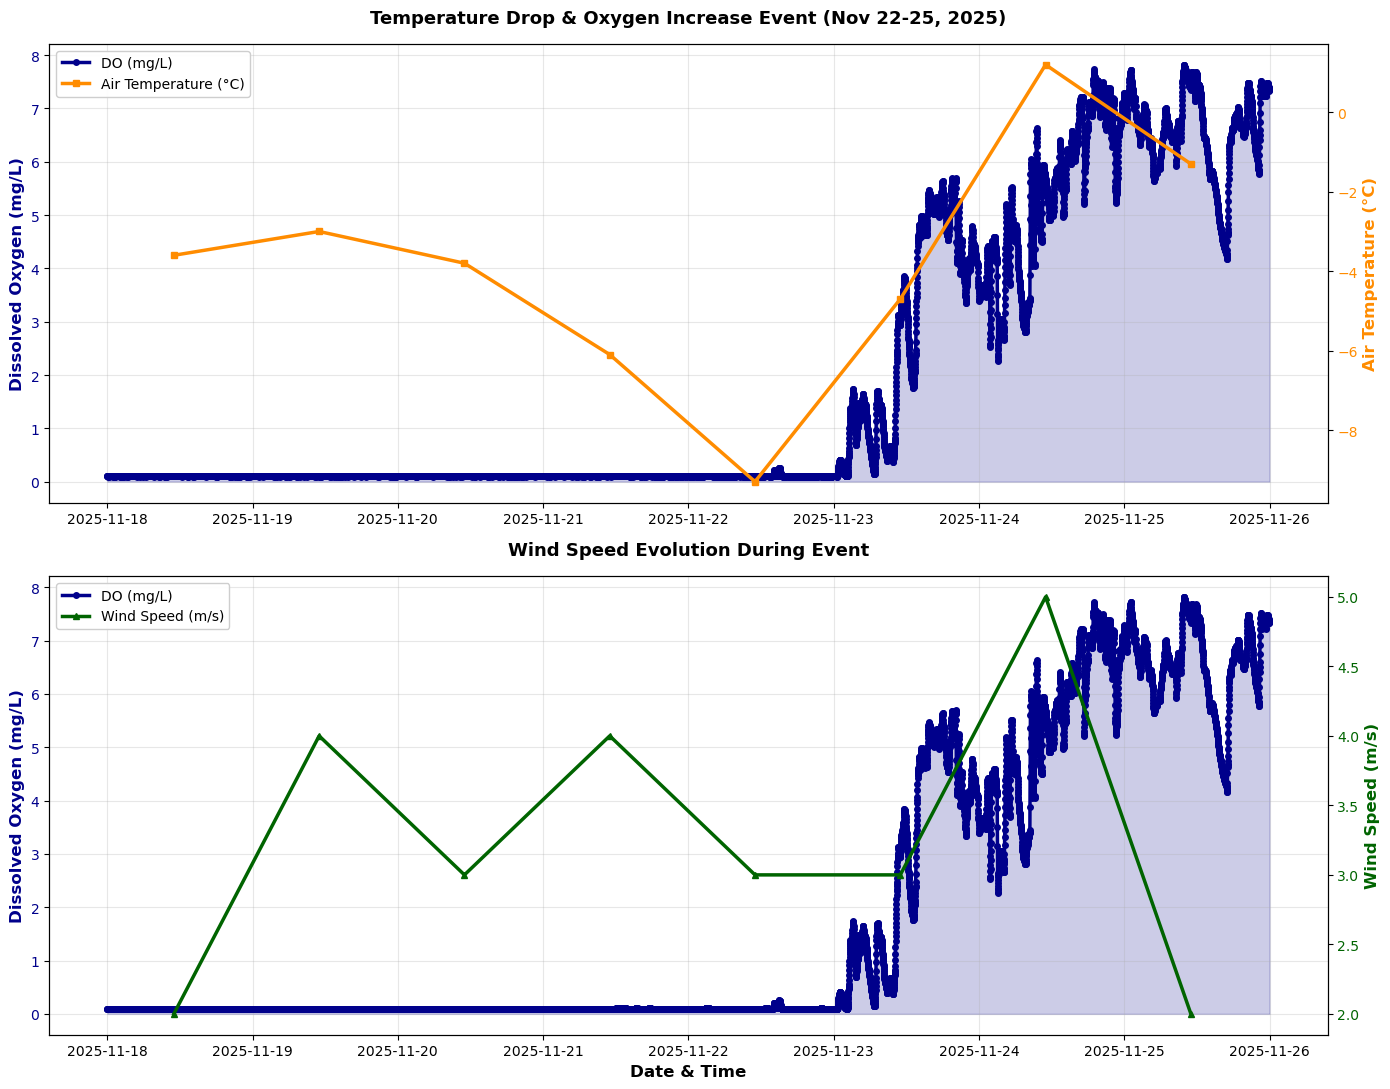

In [36]:
# Create two stacked plots: DO vs AirT and DO vs WindS (aligned to DO time series length)
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# Slice AirT and WindS to match DO time range
# Clip meteo data to the event window
do_time_start = df_drop.time.values[0]
do_time_end = df_drop.time.values[-1]
AirT_sliced = AirT.sel(time=slice(do_time_start, do_time_end))
WindS_sliced = WindS.sel(time=slice(do_time_start, do_time_end))

# Plot 1: DO vs Air Temperature
ax1 = axes[0]
ax1_twin1 = ax1.twinx()
color_do = 'darkblue'
color_airt = 'darkorange'

line1_do = ax1.plot(df_drop.time, df_drop.DO_mg, color=color_do, linewidth=2.5, marker='o', markersize=4, label='DO (mg/L)', zorder=3)
ax1.fill_between(df_drop.time, df_drop.DO_mg, alpha=0.2, color=color_do)
ax1.set_ylabel('Dissolved Oxygen (mg/L)', fontsize=12, fontweight='bold', color=color_do)
ax1.tick_params(axis='y', labelcolor=color_do, labelsize=10)
ax1.grid(True, alpha=0.3, zorder=0)

line1_airt = ax1_twin1.plot(AirT_sliced.time, AirT_sliced, color=color_airt, linewidth=2.5, marker='s', markersize=4, label='Air Temperature (°C)', zorder=2)
ax1_twin1.set_ylabel('Air Temperature (°C)', fontsize=12, fontweight='bold', color=color_airt)
ax1_twin1.tick_params(axis='y', labelcolor=color_airt, labelsize=10)

ax1.set_title('Temperature Drop & Oxygen Increase Event (Nov 22-25, 2025)', fontsize=13, fontweight='bold', pad=15)
lines1 = line1_do + line1_airt
labels1 = [l.get_label() for l in lines1]
ax1.legend(lines1, labels1, loc='upper left', fontsize=10, framealpha=0.95)

# Plot 2: DO vs Wind Speed
ax2 = axes[1]
ax2_twin2 = ax2.twinx()
color_winds = 'darkgreen'

line2_do = ax2.plot(df_drop.time, df_drop.DO_mg, color=color_do, linewidth=2.5, marker='o', markersize=4, label='DO (mg/L)', zorder=3)
ax2.fill_between(df_drop.time, df_drop.DO_mg, alpha=0.2, color=color_do)
ax2.set_ylabel('Dissolved Oxygen (mg/L)', fontsize=12, fontweight='bold', color=color_do)
ax2.tick_params(axis='y', labelcolor=color_do, labelsize=10)
ax2.set_xlabel('Date & Time', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, zorder=0)

line2_winds = ax2_twin2.plot(WindS_sliced.time, WindS_sliced, color=color_winds, linewidth=2.5, marker='^', markersize=4, label='Wind Speed (m/s)', zorder=2)
ax2_twin2.set_ylabel('Wind Speed (m/s)', fontsize=12, fontweight='bold', color=color_winds)
ax2_twin2.tick_params(axis='y', labelcolor=color_winds, labelsize=10)

ax2.set_title('Wind Speed Evolution During Event', fontsize=13, fontweight='bold', pad=15)
lines2 = line2_do + line2_winds
labels2 = [l.get_label() for l in lines2]
ax2.legend(lines2, labels2, loc='upper left', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.show()


In [37]:
print("\n" + "="*70)
print("RATE OF CHANGE ANALYSIS (DAILY)")
print("="*70)

do_daily = df_drop["DO_mg"].resample(time="1D").mean()

temp_daily = AirT_sliced.resample(time="1D").mean()
wind_daily = WindS_sliced.resample(time="1D").mean()

# Put meteo onto the same daily time axis as DO
temp_daily = temp_daily.interp(time=do_daily.time)
wind_daily = wind_daily.interp(time=do_daily.time)

valid = (
    np.isfinite(do_daily.values) &
    np.isfinite(temp_daily.values) &
    np.isfinite(wind_daily.values)
)

do_daily = do_daily[valid]
temp_daily = temp_daily[valid]
wind_daily = wind_daily[valid]

t_days = (
    (do_daily.time.values - do_daily.time.values[0])
    / np.timedelta64(1, "D")
)

# Day-to-day rate of change of DO, air temperature and wind
do_derivative = np.gradient(do_daily.values.astype(float), t_days)
temp_derivative = np.gradient(temp_daily.values.astype(float), t_days)
wind_derivative = np.gradient(wind_daily.values.astype(float), t_days)

print("\nDO CHANGE RATE (mg/L/day):")
print(f" Min: {do_derivative.min():.3f}")
print(f" Max: {do_derivative.max():.3f}")
print(f" Mean: {do_derivative.mean():.3f}")

print("\nTEMPERATURE CHANGE RATE (°C/day):")
print(f" Min: {temp_derivative.min():.3f}")
print(f" Max: {temp_derivative.max():.3f}")
print(f" Mean: {temp_derivative.mean():.3f}")

print("\nWIND SPEED CHANGE RATE (m/s/day):")
print(f" Min: {wind_derivative.min():.3f}")
print(f" Max: {wind_derivative.max():.3f}")
print(f" Mean: {wind_derivative.mean():.3f}")

# Sensitivity: DO gained per degree of air-temperature drop
mask = np.abs(temp_derivative) > 1e-6

if mask.sum() > 0:
    do_per_temp = np.mean(
        -do_derivative[mask] / temp_derivative[mask]
    )

    print("\nSENSITIVITY:")
    print(f"DO increase per °C air temperature drop: {do_per_temp:.3f} mg/L/°C")




RATE OF CHANGE ANALYSIS (DAILY)

DO CHANGE RATE (mg/L/day):
 Min: -0.000
 Max: 2.641
 Mean: 0.886

TEMPERATURE CHANGE RATE (°C/day):
 Min: -2.750
 Max: 5.250
 Mean: 0.169

WIND SPEED CHANGE RATE (m/s/day):
 Min: -3.000
 Max: 2.000
 Mean: -0.062

SENSITIVITY:
DO increase per °C air temperature drop: -0.382 mg/L/°C
